# Supernova distances and redshifts (part 1)

Measuring the cosmological relationship between distance and redshift is at the heart of the entire field of cosmology and allowed, among other things, the discovery of dark energy! At high redshifts, this is done with Type Ia Supernova which are standard (or better, standardizable) candles.

This is a [Nobel prize](https://www.nobelprize.org/prizes/physics/2011/riess/facts/) plot by [Riess et al](https://iopscience.iop.org/article/10.1086/300499)

![Screen.png](Screen.png)

Let's recall the definition of magnitude and the distance modulus (ah! the astronomers...)

$$
\mu = m-M =  5 \log_{10}\left(\frac{d_L}{\rm pc}\right) - 5
$$

Here is the Hubble diagram for Type Ia supernovae (which are standard candels). The lines show the predictions for cosmologies with varying amounts of Ωm and ΩΛ. The observed points all lie above the line for a universe with zero Λ. The lower panel, with the slope caused by the inverse square law taken out, shows the difference between the predictions more clearly and shows why a model with ΩΛ > 0 is favored. 

These are some (synthetic but realistic; see textbook) supernova data

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/308275523.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


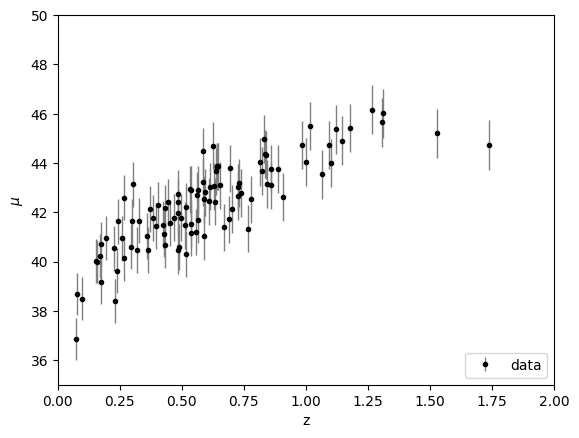

In [1]:
from matplotlib import pyplot as plt
from astroML.datasets import generate_mu_z

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/627089284.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


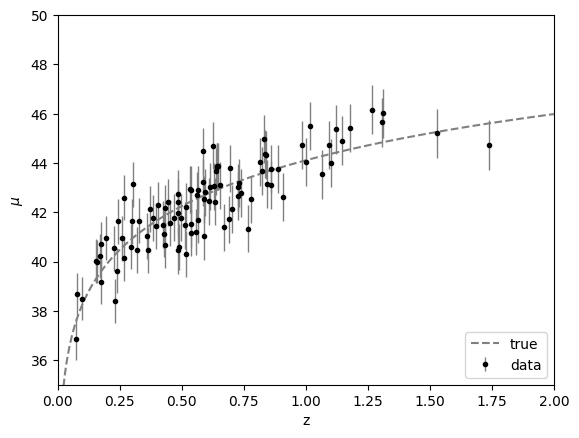

In [2]:
from astropy.cosmology import LambdaCDM
import numpy as np

cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
z = np.linspace(0.01, 2, 1000)
mu_true = cosmo.distmod(z)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(z, mu_true, '--', c='gray',label='true')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

####  Tasks

- First, explore fitting this data with the tecniques we have seen.
- Start from linear regression and polynomial regression
- For the case of  polynomial regression, just fit many of them for now.
- Let's bet based on intuition! Which fit is the best?
- In what cases are you underfitting the data?
- In what cases are you overfitting the data?
- Now split the data into training and validation sets
- Implement a cross-validation procedure
- Pick the best!
- Does it agree with our bets?

#### OPTIONAL
- Repeat with Basis Function Regression and Kernel Regression
- Explore what happens when you change the number of datapoints and plot the resulting learning curves.

In [3]:
from astroML.linear_model import PolynomialRegression, BasisFunctionRegression
from astroML.linear_model import NadarayaWatson

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error

X = z_sample.reshape(-1, 1)
y = mu_sample
dy = dmu

z_plot = np.linspace(0, 2, 500).reshape(-1, 1)

/opt/anaconda3/envs/pyrootAlbi/lib/python3.12/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


# Part 1. Different regression algorithms

### Linear Regression

- Sklearn

In [4]:
from sklearn.linear_model import LinearRegression

model_sklearn = LinearRegression()
model_sklearn.fit(X, y, sample_weight=1.0)
mu_pred_sklearn = model_sklearn.predict(z_plot)

In [5]:
print("alpha:", model_sklearn.coef_[0], "; intercept:", model_sklearn.intercept_)

alpha: 4.647118479591296 ; intercept: 39.56505554722625


- AstroML: Differently from Sklearn, it takes into account the possibility for heteroscedastic error (dmu).

In [6]:
from astroML.linear_model import LinearRegression

model_ML = LinearRegression()
model_ML.fit(X, y, dmu)
mu_pred_ML = model_ML.predict(z_plot)

In [7]:
print("alpha:", model_ML.coef_[1], "; intercept:", model_ML.coef_[0])

alpha: 4.764388647749793 ; intercept: 39.48384602295728


Comparison:

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/3990003085.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


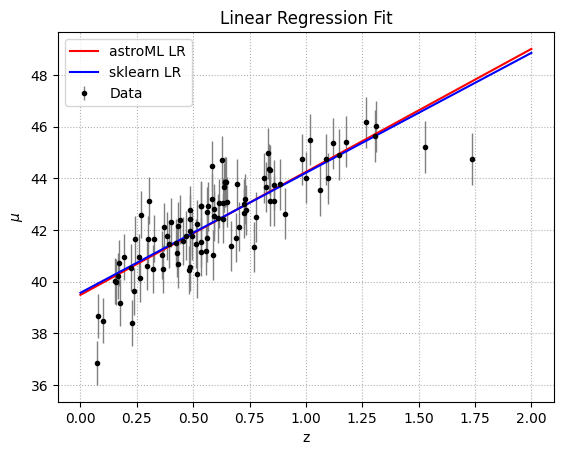

In [ ]:
# Plot
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Data')
plt.plot(z_plot, mu_pred_ML, c='red', label='astroML LR')
plt.plot(z_plot, mu_pred_sklearn, c='blue', label='sklearn LR')
plt.xlabel("z")
plt.ylabel(f"$\mu$")
plt.legend()
plt.grid(linestyle=':')
plt.title("Linear Regression Fit")
plt.show()

They return the same fit! But, the linear regression clearly underfits the data. The curve is too simple to capture the non-linear relationship between redshift and distance modulus seen in cosmological data.

### Plynomial Regression  (degrees: 1, 2, 3, 4, 5, 10, 15, 20)

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/820001239.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


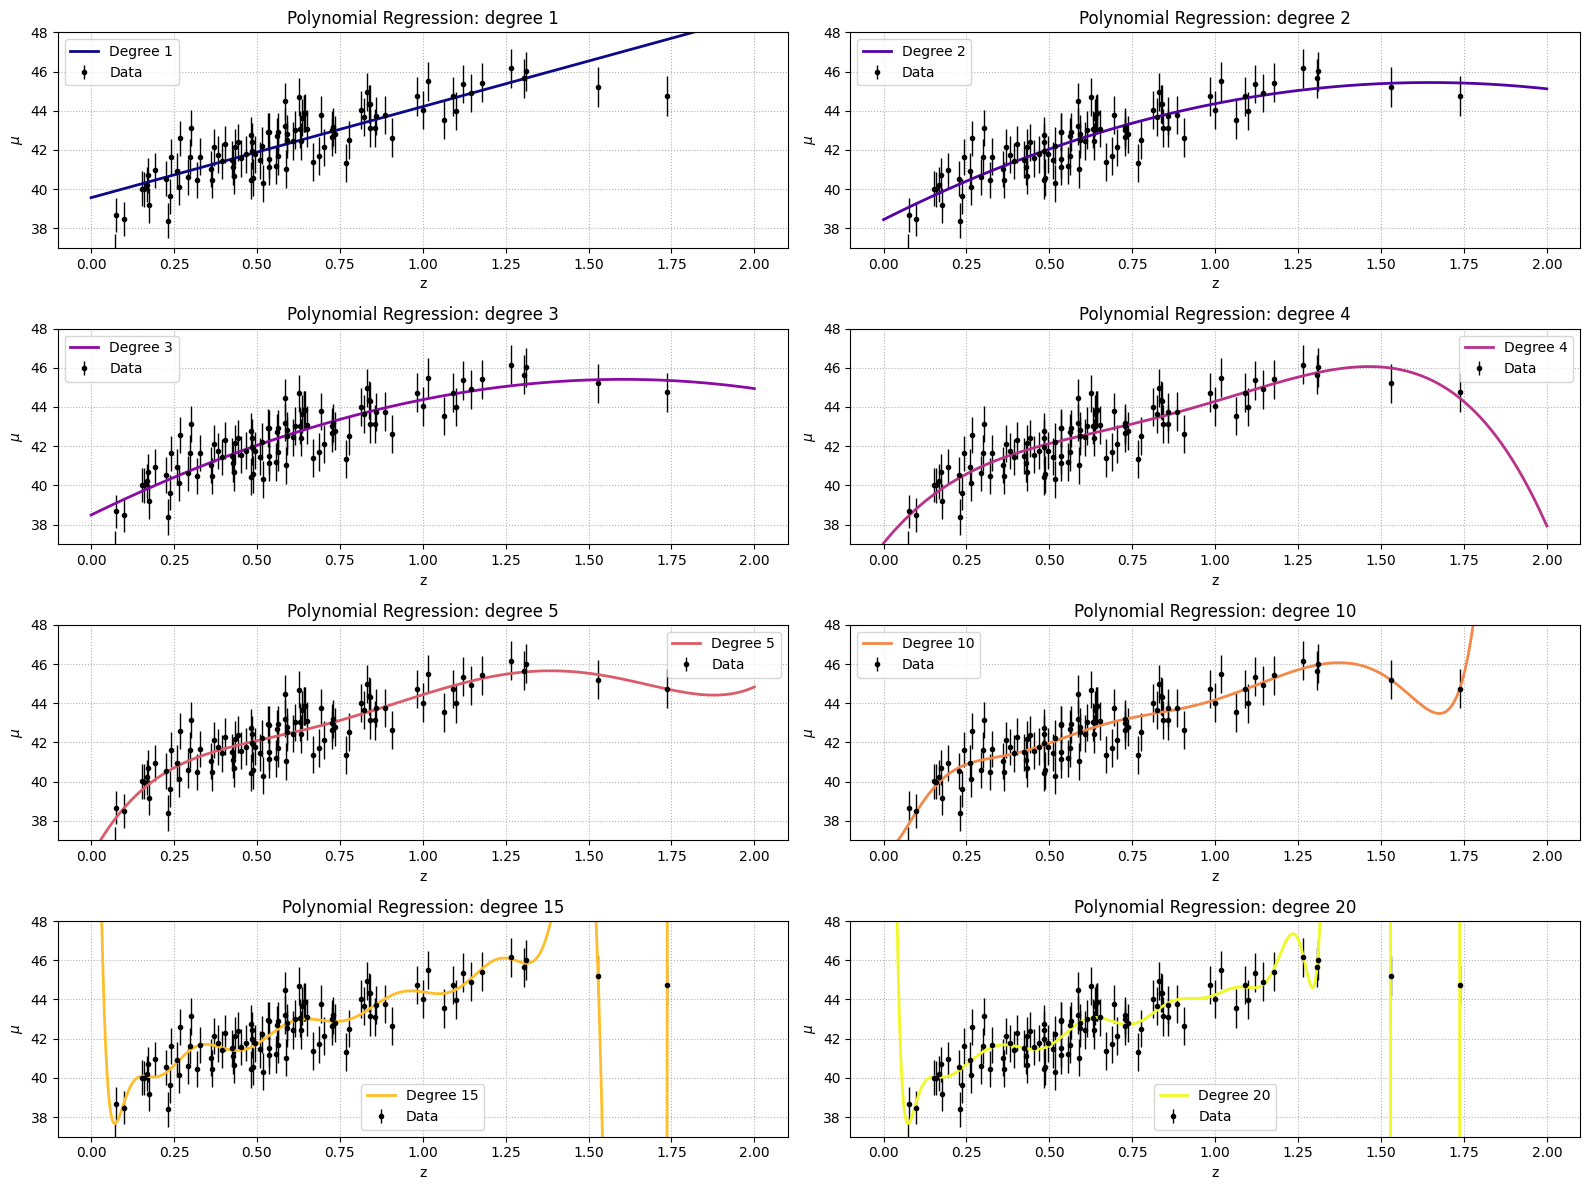

In [ ]:
from matplotlib.pyplot import get_cmap

degrees = [1, 2, 3, 4, 5, 10, 15, 20]
colors = get_cmap('plasma')(np.linspace(0, 1, len(degrees)))  # pick colors from colormap

plt.figure(figsize=(16, 12))

for i, (degree,color) in enumerate(zip(degrees,colors), 1):
    model = PolynomialRegression(degree)
    model.fit(X, y)
    y_plot = model.predict(z_plot)

    plt.subplot(4, 2, i)
    plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', lw=1, label='Data')
    plt.plot(z_plot, y_plot, lw=2, label=f"Degree {degree}", color = color)
    plt.xlabel("z")
    plt.ylabel(f"$\mu$")
    plt.ylim(37,48)
    plt.title(f"Polynomial Regression: degree {degree}")
    plt.legend()
    plt.grid(linestyle=':')

plt.tight_layout()
plt.show()


- Degree 1 behaves just like linear regression and underfits the data.
- Degrees 2 and 3 seem to capture the underlying structure quite well.
- Higher degrees like 10, 15, and 20 show signs of overfitting, creating unrealistic oscillations that don’t reflect the expected cosmological trend.

### Basis Function Regression

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/573953995.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


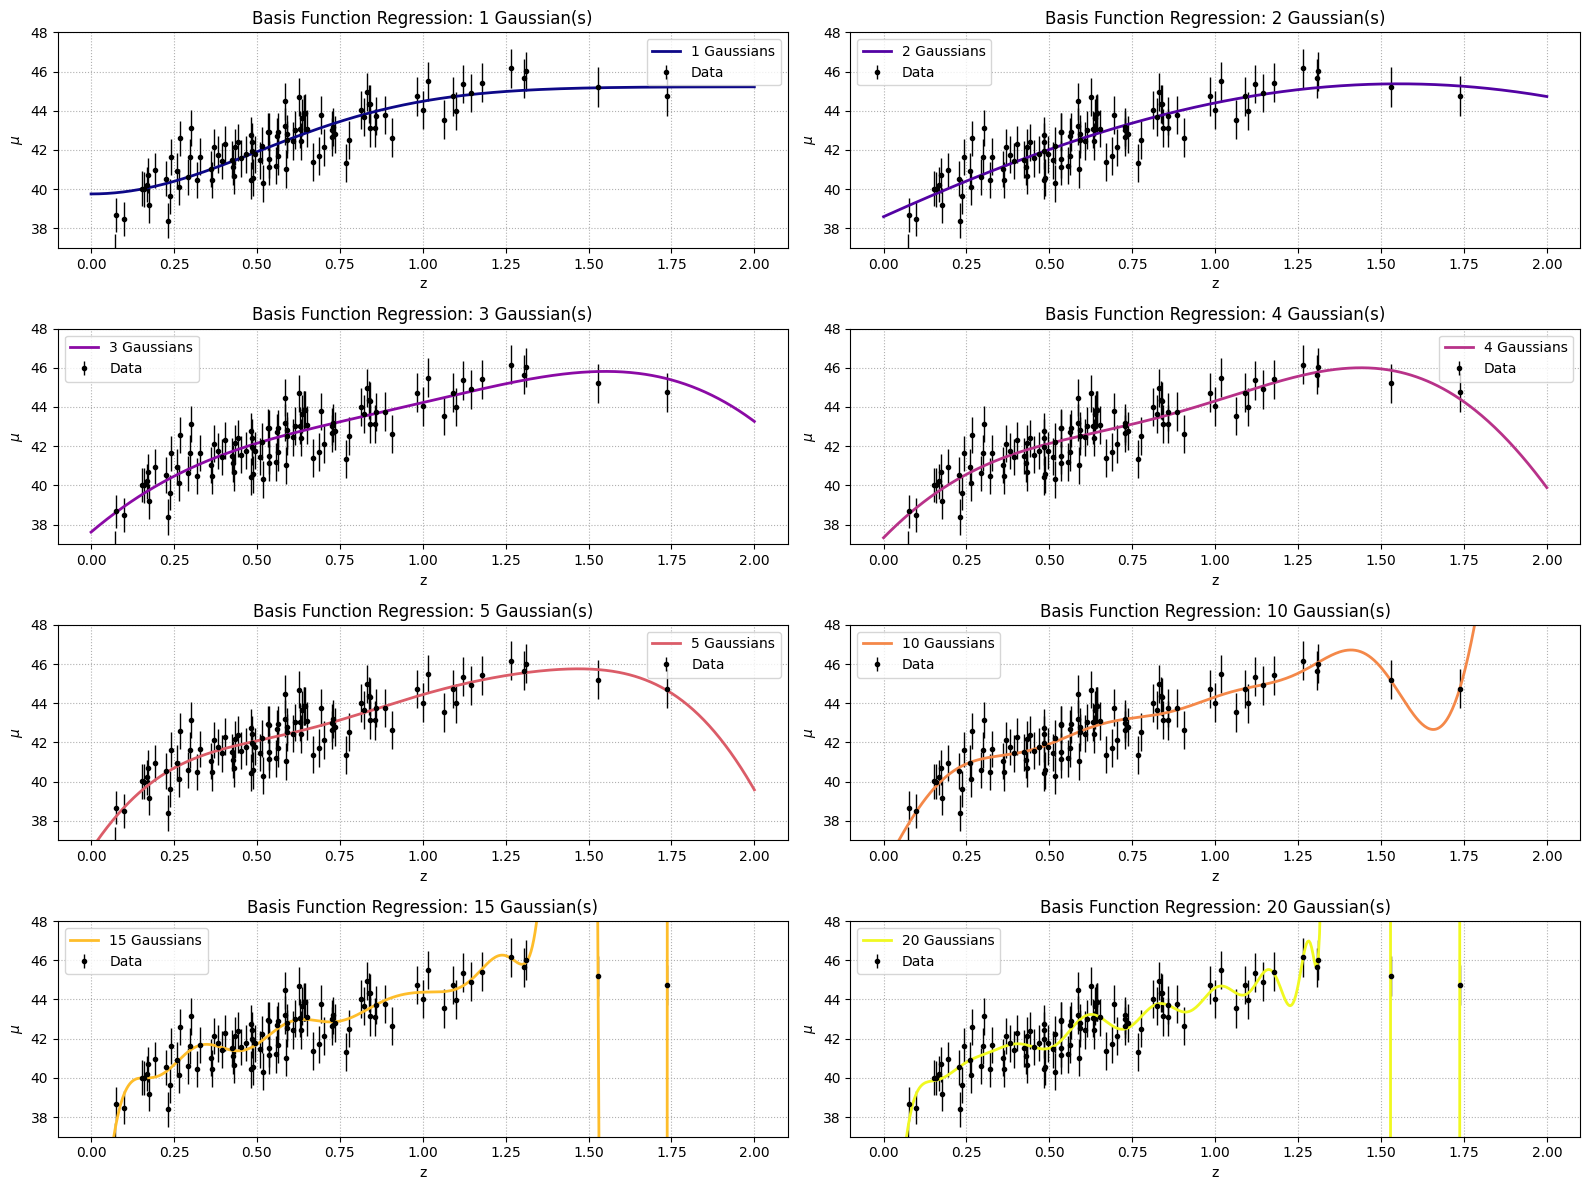

In [10]:
N_gaussians = [1, 2, 3, 4, 5, 10, 15, 20]
z_plot = np.linspace(0, 2, 500).reshape(-1, 1)
colors = get_cmap('plasma')(np.linspace(0, 1, len(N_gaussians)))  # colormap

plt.figure(figsize=(16, 12))

for i, (gaussians, color) in enumerate(zip(N_gaussians, colors), 1):
    mu = np.linspace(0, 2, gaussians)[:, None]  # Gaussian centers
    if gaussians > 1:
        sigma = mu[1] - mu[0]  # Consistent sigma
    else:
        sigma = 0.5  # Arbitrary if only one Gaussian

    model = BasisFunctionRegression('gaussian', mu=mu, sigma=sigma)
    model.fit(X, y)
    y_plot = model.predict(z_plot)

    plt.subplot(4, 2, i)
    plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', lw=1, label='Data')
    plt.plot(z_plot, y_plot, lw=2, color=color, label=f'{gaussians} Gaussians')
    plt.xlabel("z")
    plt.ylabel("$\mu$")
    plt.ylim(37, 48)
    plt.title(f"Basis Function Regression: {gaussians} Gaussian(s)")
    plt.legend()
    plt.grid(linestyle=':')

plt.tight_layout()
plt.show()


From degree 1 to 5, the model seems to adapt quite well to the data points. At higher degree we can observe overfitting.

### Kernel Regression

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/2691329519.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


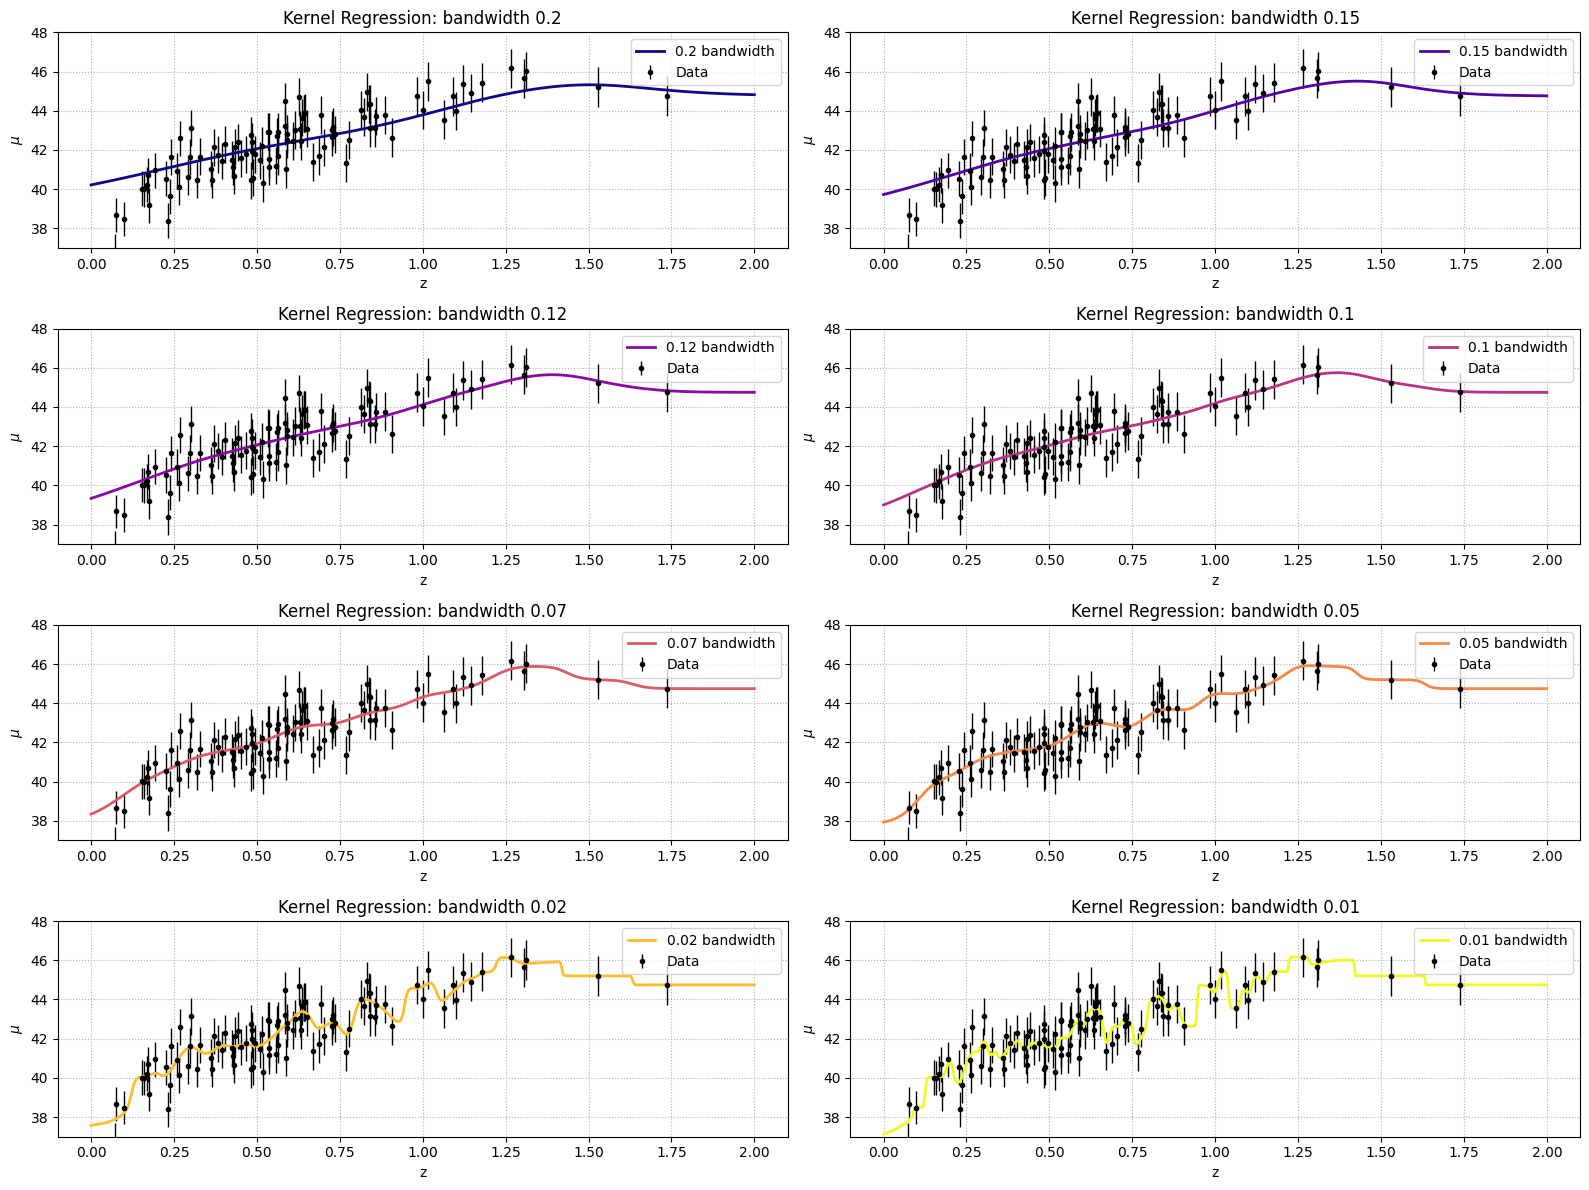

In [11]:
hs = [0.2, 0.15, 0.12, 0.1, 0.07, 0.05, 0.02, 0.01]
z_plot = np.linspace(0, 2, 500).reshape(-1, 1)
colors = get_cmap('plasma')(np.linspace(0, 1, len(N_gaussians)))  # colormap

plt.figure(figsize=(16, 12))

for i, (color, h) in enumerate(zip(colors, hs), 1):
    model = NadarayaWatson('gaussian', h=h)
    model.fit(X, y)
    y_plot = model.predict(z_plot)

    plt.subplot(4, 2, i)
    plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', lw=1, label='Data')
    plt.plot(z_plot, y_plot, lw=2, color=color, label=f'{h} bandwidth')
    plt.xlabel("z")
    plt.ylabel("$\mu$")
    plt.ylim(37, 48)
    plt.title(f"Kernel Regression: bandwidth {h}")
    plt.legend()
    plt.grid(linestyle=':')

plt.tight_layout()
plt.show()


I found this model intriguing because it didn't overfit the way the others did (very high variance). Overfit in this case means very little "maneuvre" space for newly takend data to be model-distributed. Too little the bandwidth, too little the possibility to use the model for future applications. In this case I'd choose some band between 0.2 and 0.1 , to avoid the opposite behaviour, where we lose some important behaviour of data, especially at low z.  

## Part 2. Cross validation

`GridSearchCV` only works directly with **scikit-learn-compatible estimators** (i.e., classes that implement `.fit()`, `.predict()`, and inherit from `BaseEstimator`). So I need to create wrappers around my models like `PolynomialRegression`, `BasisFunctionRegression`, and `NadarayaWatson`.


In [12]:
from sklearn.base import BaseEstimator, RegressorMixin

class PolyRegWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, degree=1):
        self.degree = degree

    def fit(self, X, y):
        self.model = PolynomialRegression(self.degree)
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)
    

class BasisFunctionWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, n_gaussians=1):
        self.n_gaussians = n_gaussians

    def fit(self, X, y):
        mu = np.linspace(0, 2, self.n_gaussians)[:, None]
        sigma = mu[1] - mu[0] if self.n_gaussians > 1 else 0.5
        self.model = BasisFunctionRegression('gaussian', mu=mu, sigma=sigma)
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)
    

class NWWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, h=0.1):
        self.h = h

    def fit(self, X, y):
        self.model = NadarayaWatson('gaussian', h=self.h)
        self.model.fit(X, y)
        return self

    def predict(self, X):
        return self.model.predict(X)

But since I don't really visualize `GridSearchCV`, I want to check the crossvalidation with another method: I decided to use the implementation of $\textit{K-Fold}$ and manually changed the number of $\textit{K-Folds}$ $k$ until I found a convergent result. I think that the outliers strongly affect the error of our model especially when taken into the testing set, so I took a better proportion of training sets (90/100). 

In [13]:
from sklearn.model_selection import KFold

#cross validation functions

def error(X, y, regressor):
    
    #print(np.sqrt( np.sum(( y - regressor.predict(X) )**2) / len(X) ))
    
    return np.sqrt( np.sum(( y - regressor.predict(X) )**2) / len(X) )

    
def cv_vs_t_err(X, y, dy, regressor_type, k):
    
    kf = KFold(n_splits=k, shuffle=True, random_state=10)  # fixed the shuffling
    
    t_err = []
    cv_err = []
    
    for t_index, cv_index in kf.split(X):
        
        regressor_type.fit(X[t_index], y[t_index], dy[t_index])
        
        t_err.append(error(X[t_index], y[t_index], regressor_type))
        cv_err.append(error(X[cv_index], y[cv_index], regressor_type))
    
    return np.median(t_err), np.median(cv_err)  # chose median because mean strongly depends on outliers

Since the linear regression does not require any additional parameter, I am starting to cross validate from the Polynomial Regression. 

### Polynomial Regression CV

In [14]:
from sklearn.model_selection import GridSearchCV

# Polynomial Regression
param_grid_poly = {'degree': [1, 2, 3, 4, 5, 10, 15, 20]}
grid_poly = GridSearchCV(PolyRegWrapper(), param_grid_poly, cv=5, scoring='neg_mean_squared_error')
grid_poly.fit(X, y)
print("Best polynomial degree:", grid_poly.best_params_['degree'])

Best polynomial degree: 2


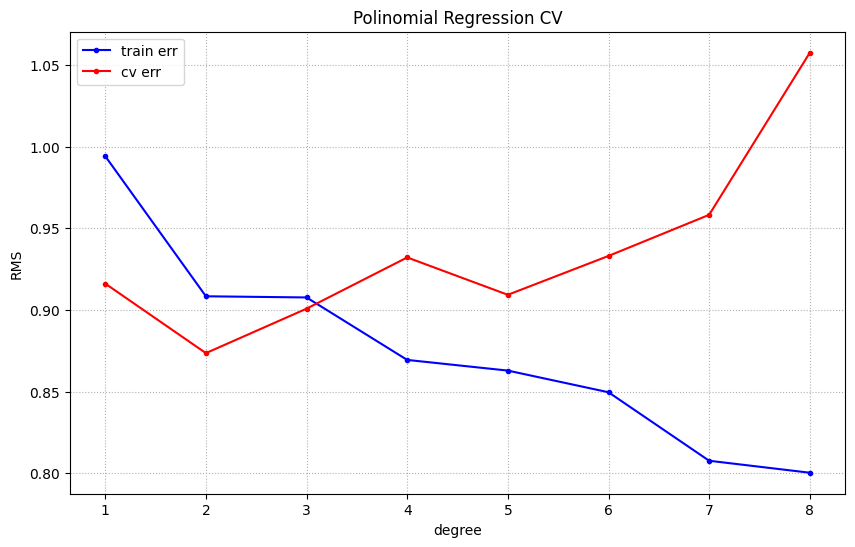

Best polynomial degree: 2 , with error value: 0.8736006812023647


In [15]:
cv_err_pr = []
t_err_pr = []

for param in degrees: 
    
    regressor_type = PolynomialRegression(param) 
    t_err_i, cv_err_i = cv_vs_t_err(X, y, dmu, regressor_type, 11)
    cv_err_pr.append(cv_err_i)
    t_err_pr.append(t_err_i)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(t_err_pr) + 1), t_err_pr, c='blue', label='train err', marker='.')
plt.plot(np.arange(1, len(cv_err_pr) + 1), cv_err_pr, c='red', label='cv err', marker='.')

plt.xlabel("degree")
plt.ylabel("RMS")
plt.title(f"Polinomial Regression CV")
plt.legend()
plt.grid(linestyle=':')
plt.show()

print("Best polynomial degree:", np.argmin(cv_err_pr) + 1, ", with error value:", np.min(cv_err_pr))

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/3812635958.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


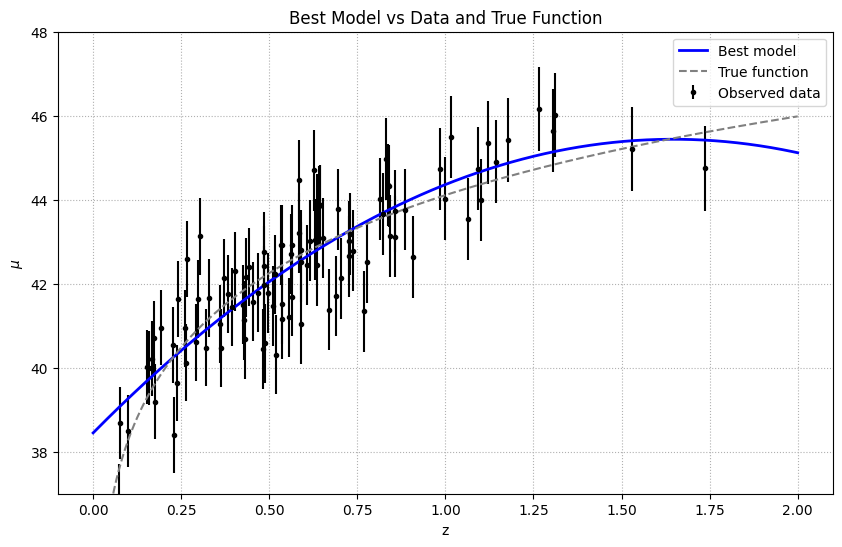

In [16]:
z_plot = np.linspace(0, 2, 500).reshape(-1, 1)
best_model = PolynomialRegression(grid_poly.best_params_['degree'])
best_model.fit(X, y)
y_plot = best_model.predict(z_plot)

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', label='Observed data')
plt.plot(z_plot, y_plot, lw=2, color='blue', label='Best model')
plt.plot(z, mu_true, '--', c='gray', label='True function')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.title("Best Model vs Data and True Function")
plt.ylim(37, 48)
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

### Basis Function Regression CV

In [17]:
# Basis Function Regression
param_grid_basis = {'n_gaussians': [1, 2, 3, 4, 5, 10, 15, 20]}
grid_basis = GridSearchCV(BasisFunctionWrapper(), param_grid_basis, cv=5, scoring='neg_mean_squared_error')
grid_basis.fit(X, y)
print("Best number of Gaussians:", grid_basis.best_params_['n_gaussians'])


Best number of Gaussians: 2


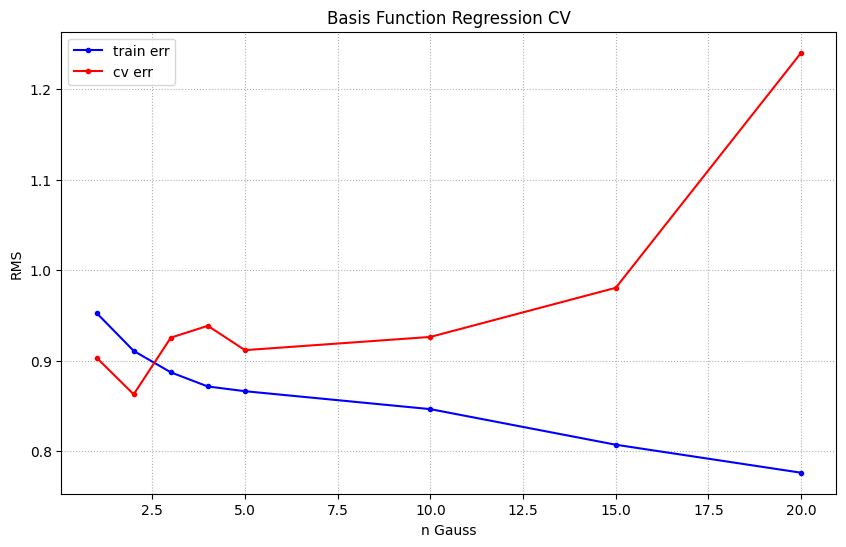

Best number of Gaussians: 2 , with error value: 0.8626607438766577


In [18]:
cv_err_bfr = []
t_err_bfr = []
    
for i in N_gaussians: 

    mu = np.linspace(0, 2, i)[:, None]  # Gaussian centers
    if i > 1:
        sigma = mu[1] - mu[0]  # Consistent sigma
    else:
        sigma = 0.5  # Arbitrary if only one Gaussian
    
    regressor_type = BasisFunctionRegression(basis_func='gaussian', mu=mu, sigma=sigma)
 
    t_err_i, cv_err_i = cv_vs_t_err(X, y, dmu, regressor_type, 11)
    cv_err_bfr.append(cv_err_i)
    t_err_bfr.append(t_err_i)
    
plt.figure(figsize=(10, 6))
plt.plot(N_gaussians, t_err_bfr, c='blue', label='train err', marker='.')
plt.plot(N_gaussians, cv_err_bfr, c='red', label='cv err', marker='.')

plt.xlabel("n Gauss")
plt.ylabel("RMS")
plt.title(f"Basis Function Regression CV")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

print("Best number of Gaussians:", N_gaussians[np.argmin(cv_err_bfr)], ", with error value:", np.min(cv_err_bfr))

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/4147142759.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


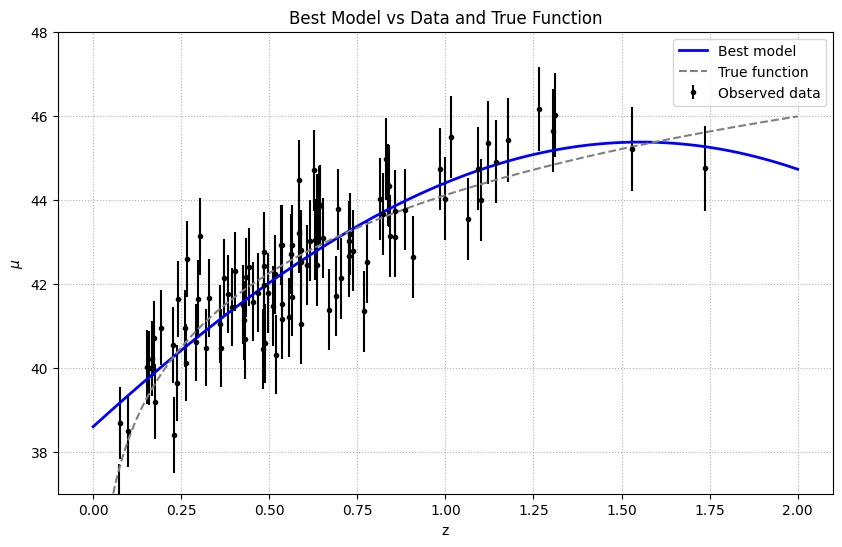

In [19]:
z_plot = np.linspace(0, 2, 500).reshape(-1, 1)
mu = np.linspace(0, 2, grid_basis.best_params_['n_gaussians'])[:, None]
sigma = mu[1]-mu[0]

best_model = BasisFunctionRegression('gaussian', mu = mu , sigma = sigma)
best_model.fit(X, y)
y_plot = best_model.predict(z_plot)

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', label='Observed data')
plt.plot(z_plot, y_plot, lw=2, color='blue', label='Best model')
plt.plot(z, mu_true, '--', c='gray', label='True function')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.title("Best Model vs Data and True Function")
plt.ylim(37, 48)
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

### Kernel Regression CV

In [20]:
# Nadaraya-Watson Regression
param_grid_nw = {'h': [0.2, 0.15, 0.12, 0.1, 0.07, 0.05, 0.02, 0.01]}
grid_nw = GridSearchCV(NWWrapper(), param_grid_nw, cv=5, scoring='neg_mean_squared_error')
grid_nw.fit(X, y)
print("Best kernel bandwidth:", grid_nw.best_params_['h'])

Best kernel bandwidth: 0.05


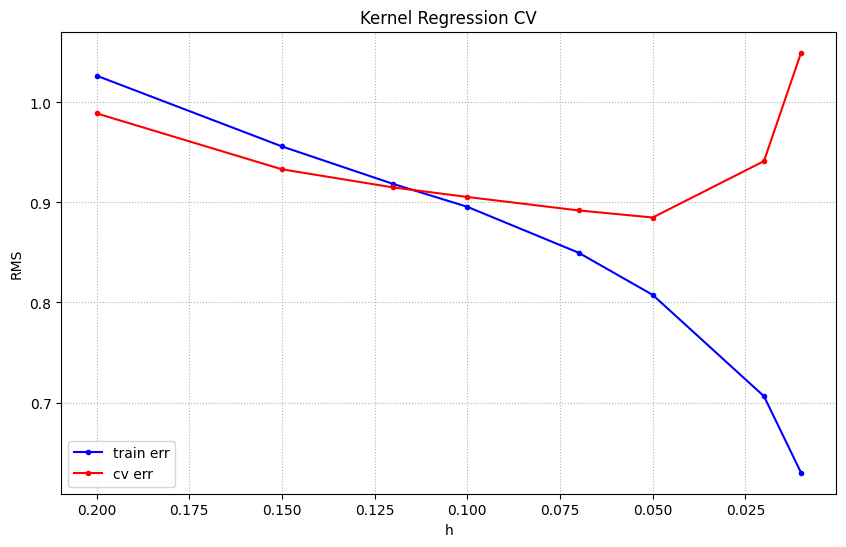

Best kernel bandwidth: 0.05 , with error value: 0.8849446377369268


In [21]:
cv_err_na = []
t_err_na = []

indexes_names = np.arange(0, 7) 
    
for i in hs:
    
    regressor_type = NadarayaWatson(kernel='gaussian', h=i)
 
    t_err_i, cv_err_i = cv_vs_t_err(X, y, dmu, regressor_type, 8)
    cv_err_na.append(cv_err_i)
    t_err_na.append(t_err_i)

plt.figure(figsize=(10, 6))
plt.plot(hs, t_err_na, c='blue', label='train err', marker='.')
plt.plot(hs, cv_err_na, c='red', label='cv err', marker='.')

plt.xlabel("h")
plt.ylabel("RMS")
plt.legend()
plt.title(f"Kernel Regression CV")
plt.legend()
plt.grid(True, linestyle=':')
plt.gca().invert_xaxis()
plt.show()

print("Best kernel bandwidth:", hs[np.argmin(cv_err_na)], ", with error value:", np.min(cv_err_na))

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/1218040675.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mu$")


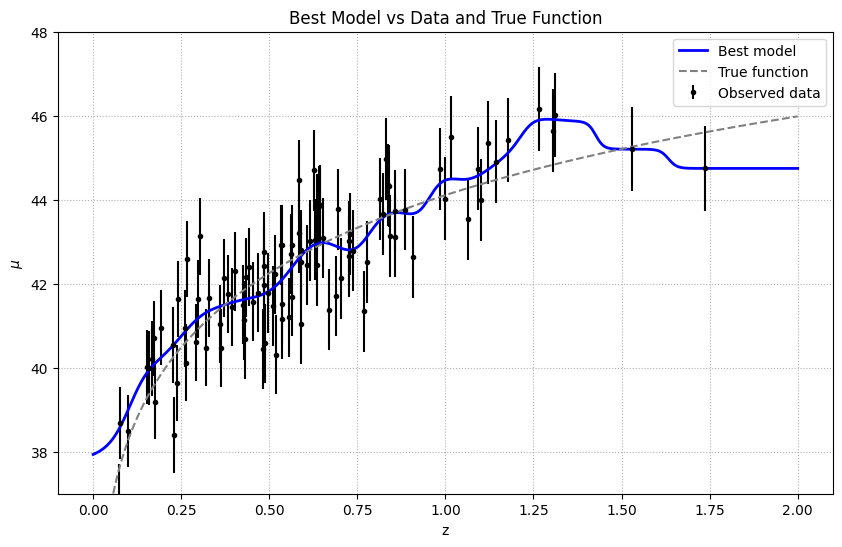

In [22]:
z_plot = np.linspace(0, 2, 500).reshape(-1, 1)

best_model = NadarayaWatson('gaussian', h=grid_nw.best_params_['h'])
best_model.fit(X, y)
y_plot = best_model.predict(z_plot)

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, yerr=dmu, fmt='.k', label='Observed data')
plt.plot(z_plot, y_plot, lw=2, color='blue', label='Best model')
plt.plot(z, mu_true, '--', c='gray', label='True function')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.title("Best Model vs Data and True Function")
plt.ylim(37, 48)
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

## Learning Curves

I now explore what happens when I change the number of datapoints and plot the resulting learning curves. I choose to set more points and then I move on to evaluate the CV and training error:

In [23]:
z_resample, mu_resample, dmu_r = generate_mu_z(1000, random_state=1234)

X_re = z_resample.reshape(-1, 1)
y_re = mu_resample

In [24]:
X_train, X_test, ydy_train, ydy_test = train_test_split(X_re, np.array([y_re, dmu_r]).T, test_size=0.33, random_state=42)
Y_train, dy_train = ydy_train.T
Y_test,dy_test = ydy_test.T

### Polynomial Regression

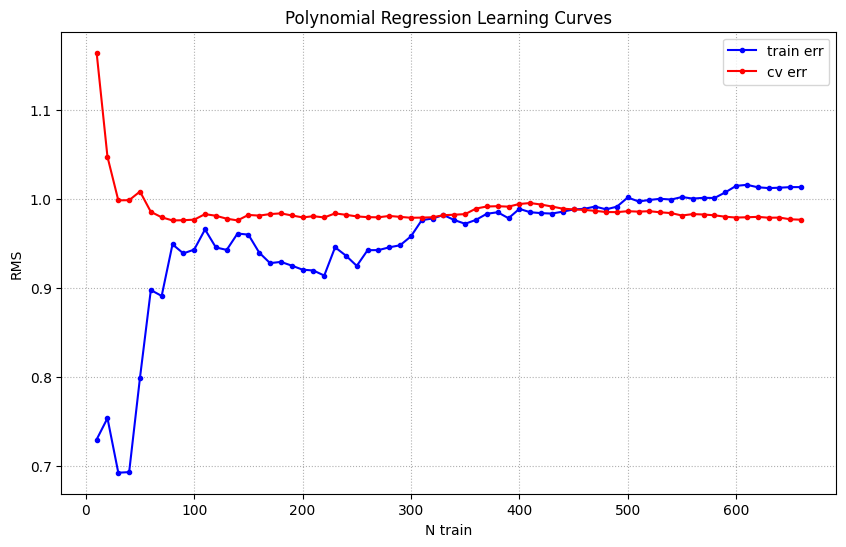

In [25]:
N_cv_err_pr = []
N_t_err_pr = []
    
for N in range(10, len(X_train), 10):
                                                                                 
    pr = PolynomialRegression(np.argmin(cv_err_pr) + 1) 
    pr.fit(X_train[:N], Y_train[:N], dy_train[:N])                                                                                                                                                            
    
    N_t_err_pr.append(error(X_train[:N], Y_train[:N], pr))                                                                       
    N_cv_err_pr.append(error(X_test, Y_test, pr))

plt.figure(figsize=(10, 6))
plt.plot(range(10, len(X_train), 10), N_t_err_pr, c='blue', label='train err', marker='.')
plt.plot(range(10, len(X_train), 10), N_cv_err_pr, c='red', label='cv err', marker='.')
plt.xlabel("N train")
plt.ylabel("RMS")
plt.title("Polynomial Regression Learning Curves")
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

### Basis Function Regression Learning Curves

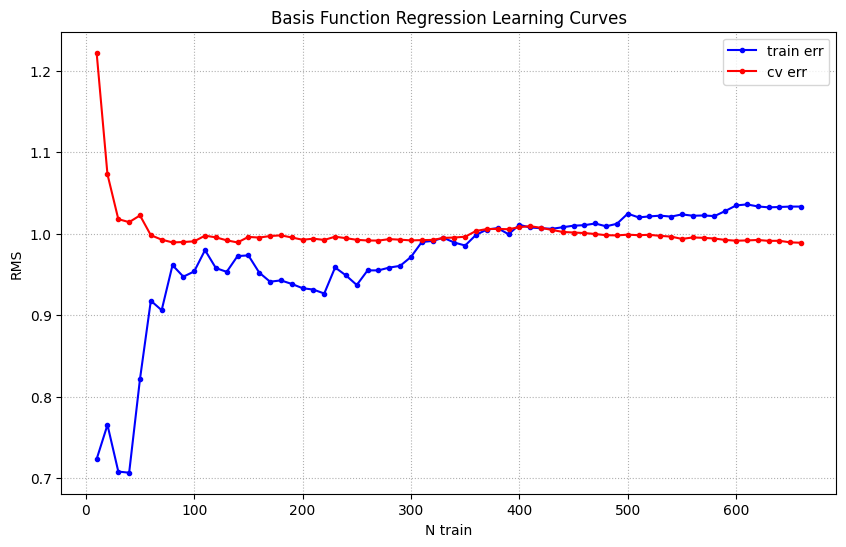

In [26]:
N_cv_err_bfr = []
N_t_err_bfr = []

for N in range(10, len(X_train), 10):
    
    # mean positions of the i Gaussians in the model
    X_gridtest = np.linspace(0, 2, N_gaussians[np.argmin(cv_err_bfr)])[:, None]
    # widths of these Gaussians
    sigma_test = X_gridtest[1]-X_gridtest[0]
                                                                                 
    bfr = BasisFunctionRegression(basis_func='gaussian', mu=X_gridtest, sigma=sigma_test) 
    bfr.fit(X_train[:N], Y_train[:N], dy_train[:N])      
                                                                                                                                                             
    N_t_err_bfr.append(error(X_train[:N], Y_train[:N], bfr))                                                                     
    N_cv_err_bfr.append(error(X_test, Y_test, bfr))


plt.figure(figsize=(10, 6))
plt.plot(range(10, len(X_train), 10), N_t_err_bfr, c='blue', label='train err', marker='.')
plt.plot(range(10, len(X_train), 10), N_cv_err_bfr, c='red', label='cv err', marker='.')
plt.xlabel("N train")
plt.ylabel("RMS")
plt.title("Basis Function Regression Learning Curves")
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

### Kernel Regression

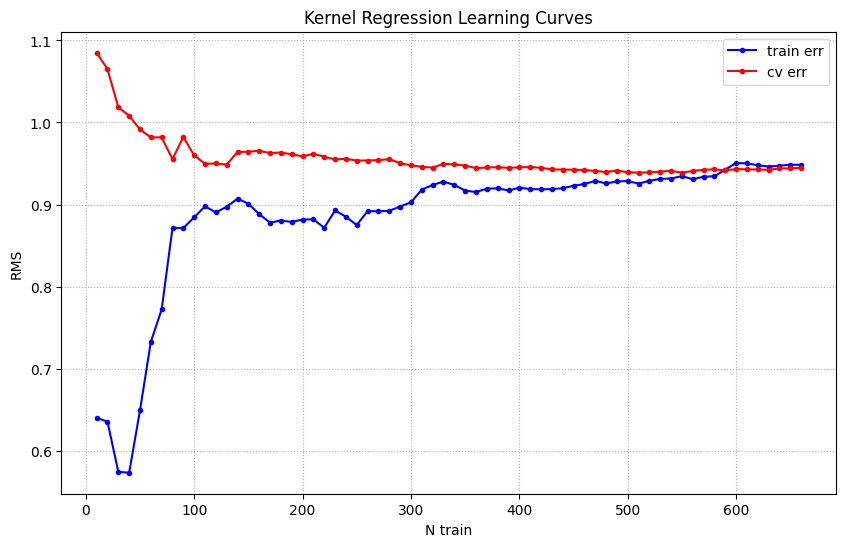

In [27]:
N_cv_err_na = []
N_t_err_na = []
    
for N in range(10, len(X_train), 10):
                                                                                 
    ndarr = NadarayaWatson(kernel='gaussian', h=hs[np.argmin(cv_err_na)])
    ndarr.fit(X_train[:N], Y_train[:N], dy_train[:N])                                                                                                                                                              
    
    N_t_err_na.append(error(X_train[:N], Y_train[:N], ndarr))                                                                            
    N_cv_err_na.append(error(X_test, Y_test, ndarr))

plt.figure(figsize=(10, 6))
plt.plot(range(10, len(X_train), 10), N_t_err_na, c='blue', label='train err', marker='.')
plt.plot(range(10, len(X_train), 10), N_cv_err_na, c='red', label='cv err', marker='.')
plt.xlabel("N train")
plt.ylabel("RMS")
plt.title("Kernel Regression Learning Curves")
plt.grid(True, linestyle=':')
plt.legend()
plt.show()

# Supernova distances and redshifts (part 2)

First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- But check out what's available in the `kernels` submodule of [sklearn.gaussian_process](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.gaussian_process)
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

*Note*. To start with, feel free to tweak the hyperparameters manually. But, of course, a publication-quality result will require a cross-validation analysis.

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.
- Think about the pdf of these data in $z$.
- Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given. 

In [28]:
# Import libraries
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
import matplotlib.pyplot as plt

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/1353214391.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Distance modulus $\mu$")


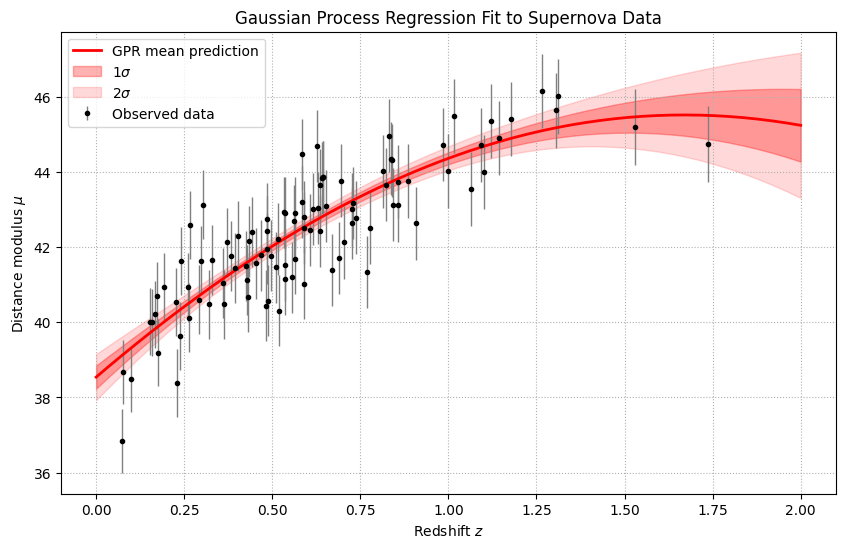

In [29]:
kernel = ConstantKernel(0.5, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) 
GPR = GaussianProcessRegressor(kernel=kernel, alpha=(dy)**2)
GPR.fit(X, y)

z_plot2 = np.linspace(0, 2)
y_pred, y_err = GPR.predict(z_plot2[:, None], return_std=True)

# Plot
plt.figure(figsize=(10, 6))
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Observed data')
plt.plot(z_plot2, y_pred, 'r-', lw=2, label='GPR mean prediction')

# 1σ and 2σ confidence intervals
plt.fill_between(z_plot2, y_pred - y_err, y_pred + y_err, color='red', alpha=0.3, label=r'1$\sigma$')
plt.fill_between(z_plot2, y_pred - 2*y_err, y_pred + 2*y_err, color='red', alpha=0.15, label=r'2$\sigma$')

plt.xlabel("Redshift $z$")
plt.ylabel("Distance modulus $\mu$")
plt.title("Gaussian Process Regression Fit to Supernova Data")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

In [30]:
from scipy.stats import gaussian_kde

# Estimate PDF of original z samples
z_pdf = gaussian_kde(z_sample)
z_clone = z_pdf.resample(10 * len(z_sample)).reshape(-1)  # Clone z values

# Optionally, clip or constrain to [0, 2]
z_clone = np.clip(z_clone, 0, 2)

In [31]:
mu_clone_mean, mu_clone_std = GPR.predict(z_clone[:, None], return_std=True)
mu_clone = np.random.normal(mu_clone_mean, mu_clone_std)

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/2176676172.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Distance modulus $\mu$")


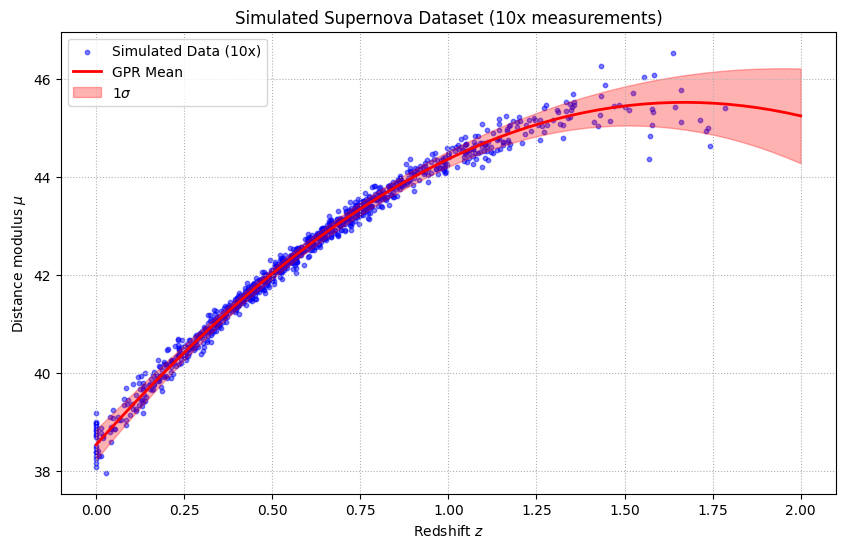

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(z_clone, mu_clone, s=10, alpha=0.5, color='blue', label='Simulated Data (10x)')
plt.plot(z_plot2, y_pred, 'r-', lw=2, label='GPR Mean')
plt.fill_between(z_plot2, y_pred - y_err, y_pred + y_err, color='red', alpha=0.3, label=r'1$\sigma$')

plt.xlabel("Redshift $z$")
plt.ylabel("Distance modulus $\mu$")
plt.title("Simulated Supernova Dataset (10x measurements)")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# Part 3 (for the exam)

*(I know this assignment is longer and more convoluted, but we're getting towards the end of the class and it's important to draw connections between the different things we've done)*

We now have a suite of **data-driven** predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

This is already great and these kind of tools are immensely useful in a variety of contexts (also involving a lot of money: suppose you want to predict how much a give financial asset will perform on tomorrow's stock market... You  might not really care about expressing the underlying financial model in simple terms, as long as your investments are profitable).

For the case of supernovae, however, we have do have physical theory which is $\Lambda$ CDM. We can do a **parametric** fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

- First, refresh your cosmology and write down the predicted relationship between the distance module $\mu$ and the redshift $\sigma$. *Hint* I always forget these things, my to-go reference is [Hogg (2010)](https://arxiv.org/abs/astro-ph/9905116). The answer is:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$

- Assuming a flat Universe,  we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$
- It's a very non-linear model. Fit it to the data, however you want to do it, using tecniques we've seen throughout the course. Some ideas:
    - Set up a Bayesian framework and use MCMC. 
    - Set up a fully-connected neural network (see end of the class).

- What are the measured value of $H_0$ and $\Omega_m$. What's they errors? Are they correlated?
- How would a model without dark energy (i.e. $\Omega_m=1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem!)





In [33]:
import numpy as np
import pandas as pd
from astropy.cosmology import FlatLambdaCDM
import emcee
import corner
import matplotlib.pyplot as plt

In [34]:
def model_mu(z, theta):
    Om0, H0 = theta
    if Om0 >0: 
        c = FlatLambdaCDM(H0, Om0)
        return c.distmod(z).value
    return 0

### MCMC Sampling

In [35]:
def log_likelihood(theta, z, mu_obs, mu_err):
    Om0, H0 = theta
    mu_model = model_mu(z, theta)
    return -0.5 * np.sum( np.log(2*np.pi*mu_err**2) + ((mu_obs - mu_model) / mu_err)**2)

def log_prior(theta):
    Om0, H0 = theta
    if 0.0 < Om0 < 1.0 and 40 < H0 < 100:
        return 0.0
    return -np.inf

def log_posterior(theta, z, mu_obs, mu_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z, mu_obs, mu_err)

In [36]:
ndim = 2
n_steps = 10000
nwalkers = 8

initial_guess = [0.3, 70]
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(z_sample, mu_sample, dmu))
sampler.run_mcmc(pos, n_steps, progress=True);

100%|██████████| 10000/10000 [19:55<00:00,  8.36it/s]  


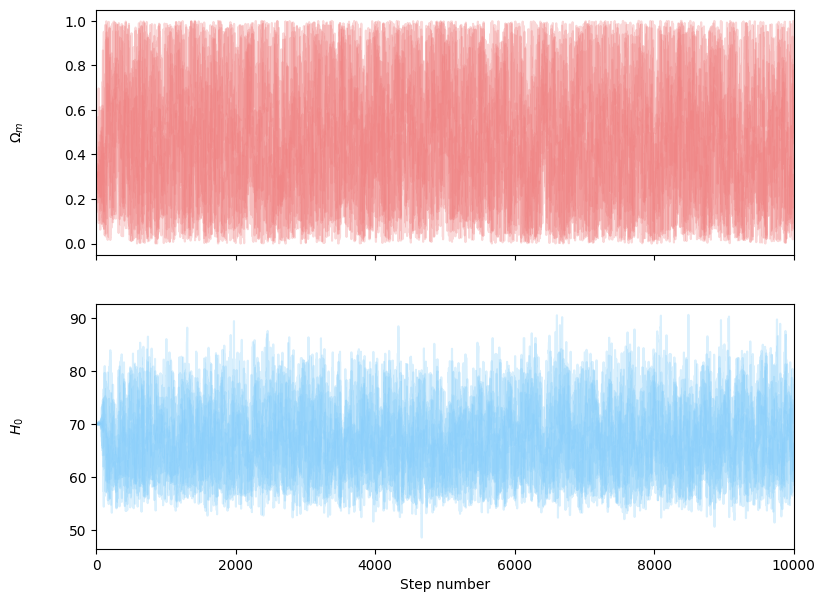

In [37]:
fig, axes = plt.subplots(2, figsize=(9, 7), sharex=True)

samples = sampler.get_chain()

labels = [r"$\Omega_{m}$", r"$H_0$"]
colors = ["lightcoral", "lightskyblue"]  # Assign a color for each parameter

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], c=colors[i], alpha=0.3)
    ax.set_xlim(0, samples.shape[0])  # Automatically use chain length
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("Step number")
plt.show()


In [38]:
tau = sampler.get_autocorr_time()
burn = 100

flat_samples = sampler.get_chain(discard=burn, thin=int(np.max(tau)), flat=True) 

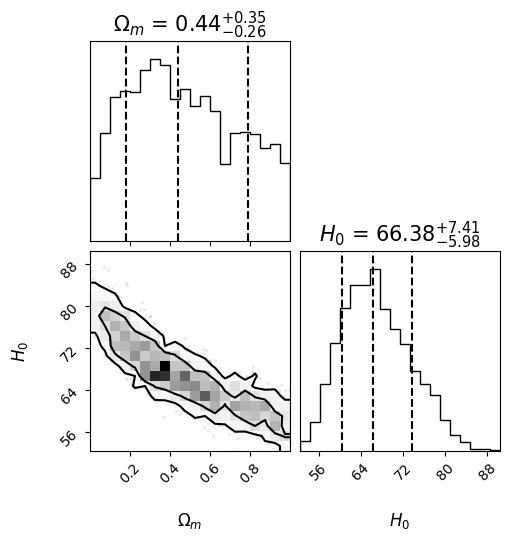

In [39]:
fig = corner.corner(
    flat_samples, labels=[r"$\Omega_{m}$", r"$H_0$"], quantiles=[0.16, 0.5, 0.84],  
    levels=([0.68, 0.95]), show_titles=True, title_kwargs={"fontsize": 15}, label_kwargs=dict(fontsize=12)
);

In [40]:
from IPython.display import display, Math

labels_output = [r"\Omega_{m}", r"H_0"]  # no $ signs here

for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = r"${0} = {1:.3f}_{{-{2:.3f}}}^{{+{3:.3f}}}$".format(labels_output[i], mcmc[1], q[0], q[1])
    display(Math(txt))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [41]:
corr_matrix = np.corrcoef(flat_samples.T)
corr = corr_matrix[0, 1]

print(f"Correlation coefficient between Ωₘ and H₀: {corr:.3f}")

Correlation coefficient between Ωₘ and H₀: -0.871


/opt/anaconda3/envs/pyrootAlbi/lib/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py:1110: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


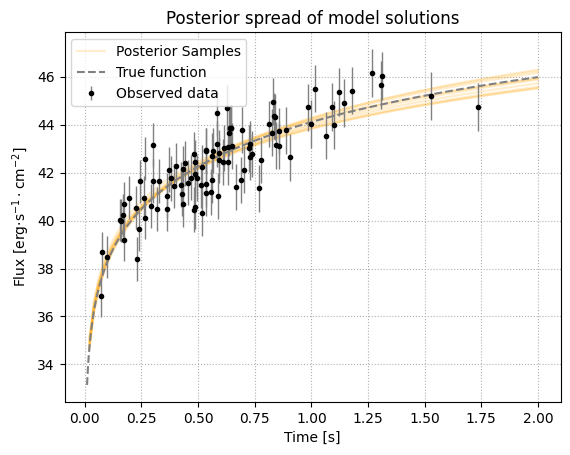

In [42]:
z_plot = np.linspace(0,2,100)

idx = np.random.choice(len(flat_samples), size=10, replace=False)
random_samples = flat_samples[idx]

for i, theta in enumerate(random_samples):
    y_model = model_mu( z_plot, theta)
    label = "Posterior Samples" if i == 0 else None
    plt.plot(z_plot, y_model, color='orange', alpha=0.2, label=label)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Observed data')
plt.plot(z, mu_true, '--', c='gray', label='True function')

plt.title("Posterior spread of model solutions")
plt.xlabel("Time [s]")
plt.ylabel(r"Flux [erg$\cdot$s$^{-1}\cdot$cm$^{-2}$]")
plt.grid(linestyle=":")
plt.legend()
plt.show()

## Model Comparison: Nested Sampling 

### Model with Dark Energy 

Same as MCMC, we expect to find the same results.

In [43]:
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty.utils import resample_equal

In [44]:
def loglike_lcdm(theta):
    Om0, H0 = theta
    if Om0 <= 0 or Om0 >= 1:
        return -np.inf
    
    cosmo = FlatLambdaCDM(H0=H0, Om0=Om0)
    mu_model = cosmo.distmod(z_sample).value
    
    chi2 = np.sum(((mu_sample - mu_model) / dmu)**2)
    return -0.5 * chi2

def prior_transform_lcdm(u):
    uOm0, uH0 = u
    Om0 = 0.05 + 0.95 * uOm0     # Uniform prior [0.05, 1.0]
    H0 = 40 + 60 * uH0           # Uniform prior [40, 100]
    return Om0, H0

In [45]:
sampler_lcdm = NestedSampler(loglike_lcdm, prior_transform_lcdm, ndim=2)
sampler_lcdm.run_nested()
res_lcdm = sampler_lcdm.results

1644it [01:52, 14.58it/s, +500 | bound: 0 | nc: 1 | ncall: 12509 | eff(%): 17.853 | loglstar:   -inf < -46.385 <    inf | logz: -48.818 +/-  0.046 | dlogz:  0.001 >  0.509]


In [46]:
logZ_lcdm = res_lcdm.logz[-1]           # value of logZ
logZerr_lcdm = res_lcdm.logzerr[-1]     # estimate of the statistcal uncertainty on logZ     

print('Marginalised evidence (using static sampler) is {} ± {}'.format(logZ_lcdm, logZerr_lcdm))

Marginalised evidence (using static sampler) is -48.81760234269295 ± 0.11704446215648538


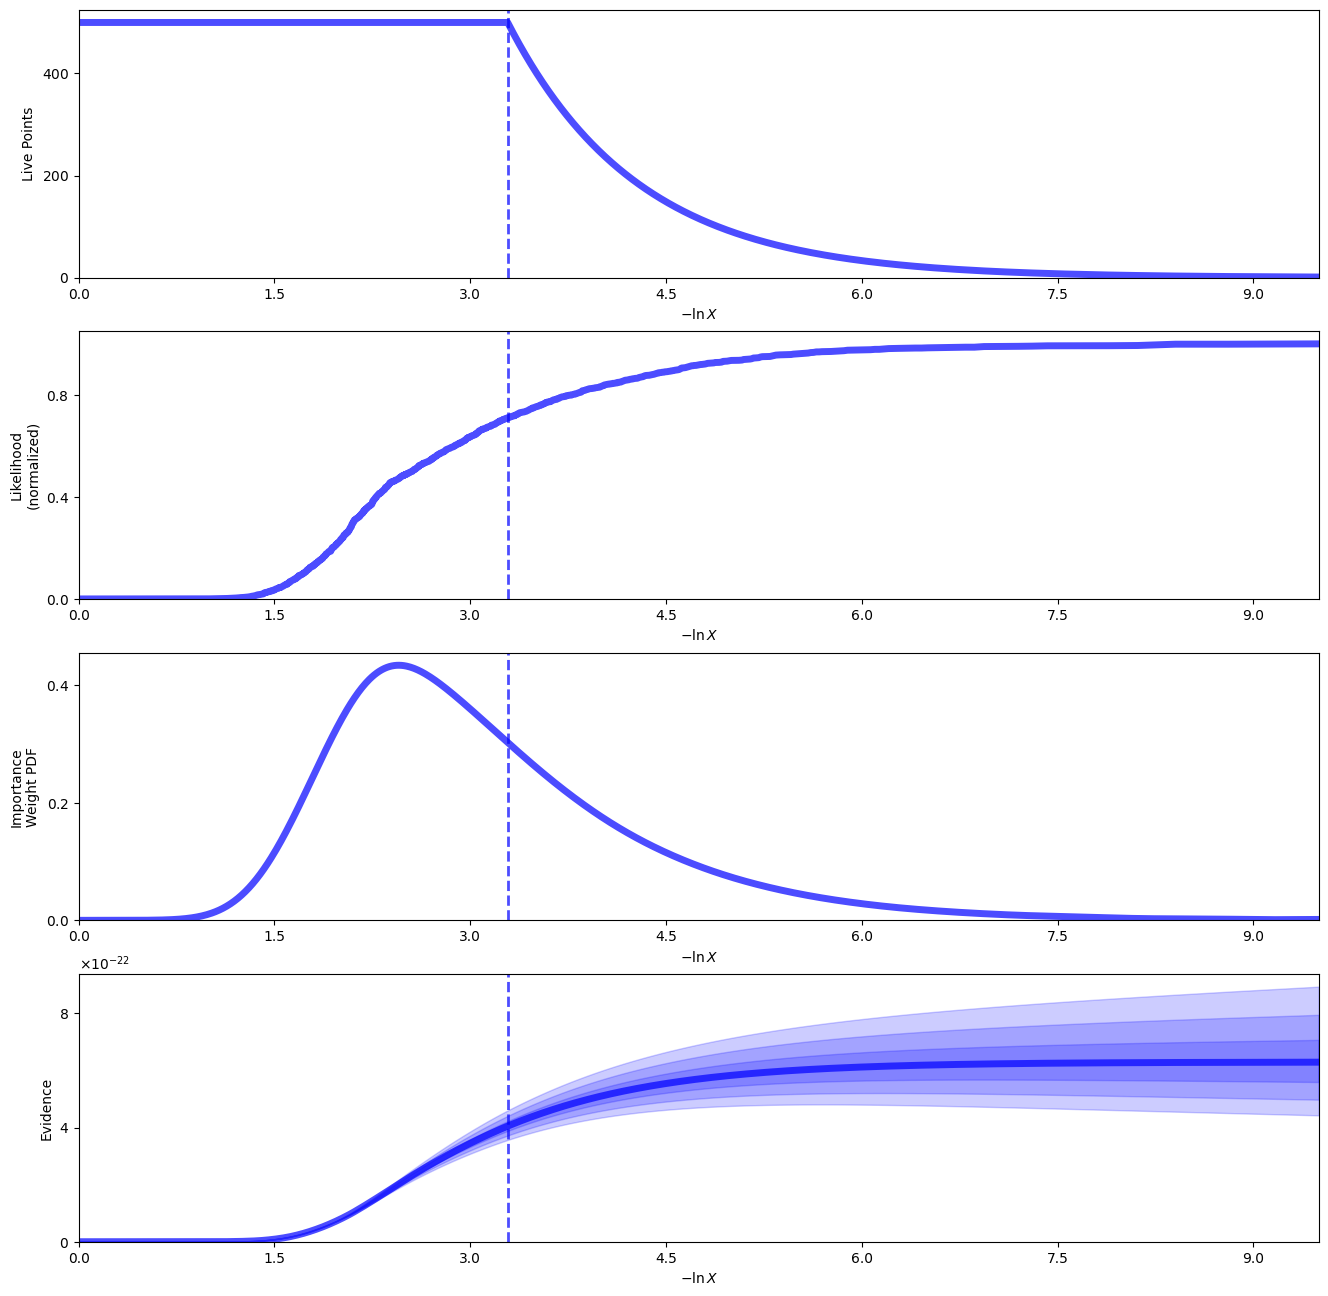

In [47]:
rfig, raxes = dyplot.runplot(res_lcdm)

<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:4: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/408757521.py:4: SyntaxWarning: invalid escape sequence '\O'
  taxes[0][0].set_ylabel("$\Omega_{m}$")
/var/folders/57/gp84p4410yx1sr6bqvtc5qs00000gn/T/ipykernel_34090/408757521.py:5: SyntaxWarning: invalid escape sequence '\O'
  taxes[0][1].set_xlabel("$\Omega_{m}$")


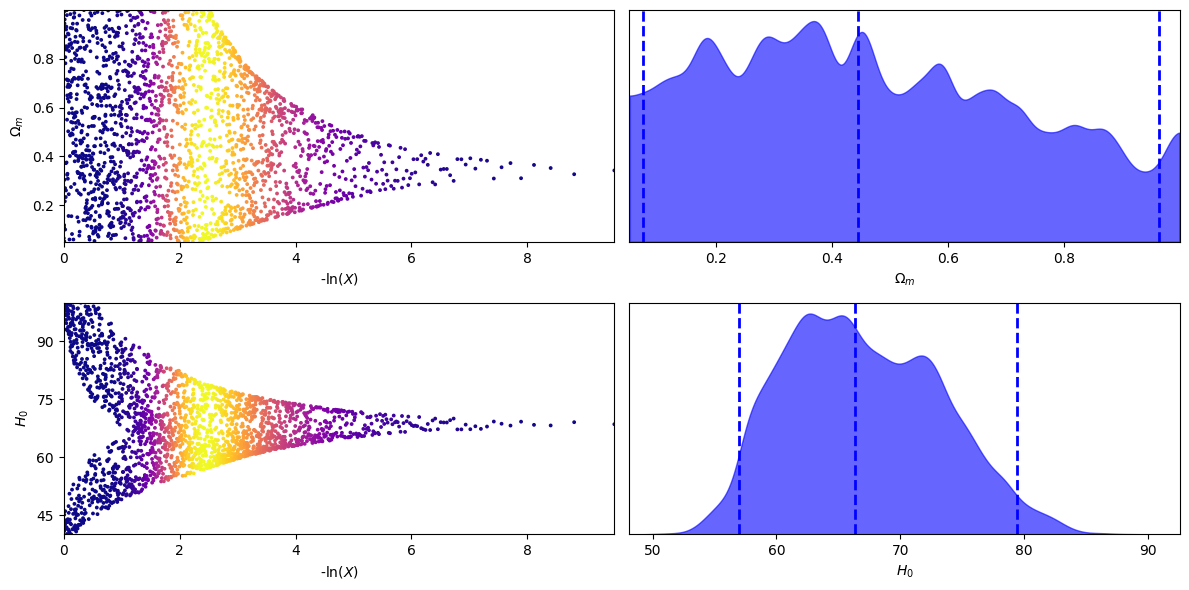

In [48]:
tfig, taxes = dyplot.traceplot(res_lcdm, trace_cmap='plasma', trace_color=None)

taxes[0][0].set_xlabel("-$\\ln(X)$")
taxes[0][0].set_ylabel("$\Omega_{m}$")
taxes[0][1].set_xlabel("$\Omega_{m}$")


taxes[1][0].set_xlabel("-$\\ln(X)$")
taxes[1][0].set_ylabel("$H_0$")
taxes[1][1].set_xlabel("$H_0$")


tfig.tight_layout()

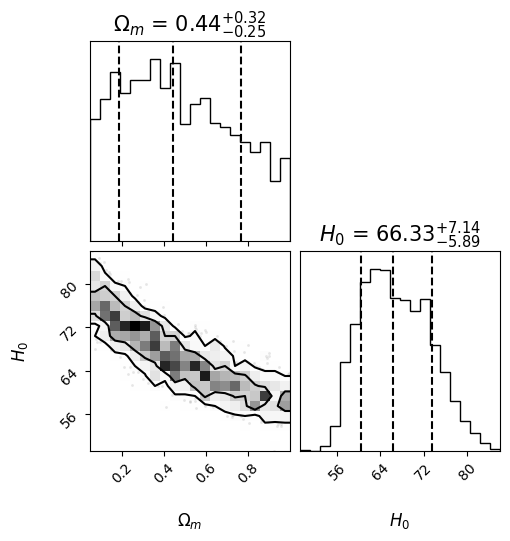

In [49]:
weights = np.exp(res_lcdm['logwt'] - res_lcdm['logz'][-1])
postsamples = resample_equal(res_lcdm.samples, weights)

fig = corner.corner(
    postsamples, labels=[r"$\Omega_{m}$", r"$H_0$"], quantiles=[0.16, 0.5, 0.84],  
    levels=([0.68, 0.95]), show_titles=True, title_kwargs={"fontsize": 15}, label_kwargs=dict(fontsize=12)
);

In [50]:
corr_matrix = np.corrcoef(postsamples.T)
corr = corr_matrix[0, 1]

print(f"Correlation coefficient between Ωₘ and H₀: {corr:.3f}")

Correlation coefficient between Ωₘ and H₀: -0.865


### Model with no Dark Energy

In [51]:
def model_noDE(z, H0):
    cosmo = FlatLambdaCDM(H0=H0, Om0=1.0)
    mu_model = cosmo.distmod(z).value

    return mu_model


def loglike_noDE(theta):
    (H0,) = theta
    
    cosmo = FlatLambdaCDM(H0=H0, Om0=1.0)
    mu_model = cosmo.distmod(z_sample).value
    
    chi2 = np.sum(((mu_sample - mu_model) / dmu)**2)
    return -0.5 * chi2

def prior_transform_noDE(u):
    uH0 = u[0]
    H0 = 40 + 60 * uH0   # Uniform prior [40, 100]
    return (H0,)

In [52]:
# No dark energy model
sampler_noDE = NestedSampler(loglike_noDE, prior_transform_noDE, ndim=1)
sampler_noDE.run_nested()
res_noDE = sampler_noDE.results

1544it [01:45, 14.62it/s, +500 | bound: 0 | nc: 1 | ncall: 11851 | eff(%): 18.007 | loglstar:   -inf < -47.102 <    inf | logz: -49.287 +/-  0.035 | dlogz:  0.001 >  0.509]


In [53]:
logZ_noDE = res_noDE.logz[-1]
logZerr_noDE = res_noDE.logzerr[-1]

print('Marginalised evidence (using static sampler) is {} ± {}'.format(logZ_noDE, logZerr_noDE))

Marginalised evidence (using static sampler) is -49.28659360181444 ± 0.11203338653167458


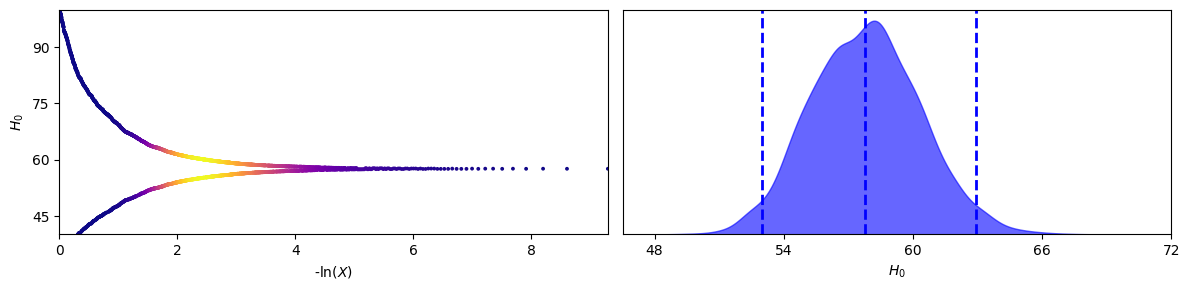

In [54]:
tfig, taxes = dyplot.traceplot(res_noDE, trace_cmap='plasma', trace_color=None)

taxes[0][0].set_xlabel("-$\\ln(X)$")
taxes[0][0].set_ylabel("$H_0$")
taxes[0][1].set_xlabel("$H_0$")


tfig.tight_layout()

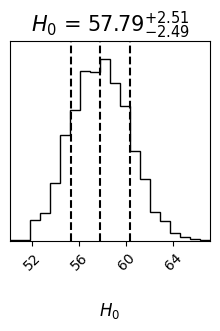

In [55]:
weights = np.exp(res_noDE.logwt - res_noDE.logz[-1])  # normalized weights
postsamples_noDE = resample_equal(res_noDE.samples, weights)

fig = corner.corner(
    postsamples_noDE, labels=[r"$H_0$"], quantiles=[0.16, 0.5, 0.84],  
    levels=([0.68, 0.95]), show_titles=True, title_kwargs={"fontsize": 15}, label_kwargs=dict(fontsize=12)
);

/opt/anaconda3/envs/pyrootAlbi/lib/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py:1110: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


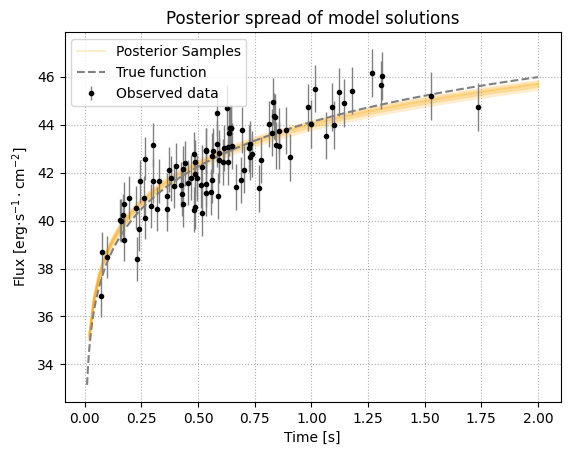

In [56]:
z_plot = np.linspace(0,2,100)

idx = np.random.choice(len(postsamples_noDE), size=10, replace=False)
random_samples = postsamples_noDE[idx]

for i, sample in enumerate(random_samples):
    H0 = sample[0]
    y_model = model_noDE(z_plot, H0)
    label = "Posterior Samples" if i == 0 else None
    plt.plot(z_plot, y_model, color='orange', alpha=0.2, label=label)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='Observed data')
plt.plot(z, mu_true, '--', c='gray', label='True function')

plt.title("Posterior spread of model solutions")
plt.xlabel("Time [s]")
plt.ylabel(r"Flux [erg$\cdot$s$^{-1}\cdot$cm$^{-2}$]")
plt.grid(linestyle=":")
plt.legend()
plt.show()

### Model Comparison

In [57]:
B_12 = np.exp(logZ_lcdm) / np.exp(logZ_noDE)
print("Bayesian factor:", B_12)

Bayesian factor: 1.5983810274392027


The fact I obtained $B_{1,2} \sim 2$ indicates that we cannot choose between one model or the other.